In [1]:
import pandas as pd
import numpy as np
import boto3
import joblib
import os
import seaborn as sns
import matplotlib.pyplot as plt
from category_encoders import TargetEncoder
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn import clone

In [2]:
base_path = os.path.join(os.path.dirname(os.path.abspath('')), "data\\car_prices.csv")
df = pd.read_csv(base_path)

##### Inflation level

In [3]:
df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce', utc=True)
df['sale_year'] = np.where(df['saledate'].isna(), df['year'], df['saledate'].dt.year).astype(int)

C:\Users\CTK109\AppData\Local\Temp\ipykernel_2316\3888026751.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce', utc=True)


In [4]:
inflation_history = {
    1982: 3.80, 1983: 3.80, 1984: 3.90, 1985: 3.80, 1986: 1.10,
    1987: 4.40, 1988: 4.40, 1989: 4.60, 1990: 6.10, 1991: 3.10,
    1992: 2.90, 1993: 2.70, 1994: 2.70, 1995: 2.50, 1996: 3.30,
    1997: 1.70, 1998: 1.60, 1999: 2.70, 2000: 3.40, 2001: 1.60,
    2002: 2.40, 2003: 1.90, 2004: 3.30, 2005: 3.40, 2006: 2.50,
    2007: 4.10, 2008: 0.10, 2009: 2.70, 2010: 1.50, 2011: 3.00,
    2012: 1.70, 2013: 1.50, 2014: 0.80, 2015: 0.70, 2016: 2.10,
    2017: 2.10, 2018: 1.90, 2019: 2.30, 2020: 1.40, 2021: 7.00,
    2022: 6.50, 2023: 3.40, 2024: 2.90, 2025: 2.68, 2026: 2.77
}

rates = pd.Series(inflation_history) / 100 + 1
cpi_timeline = rates.cumprod()

cpi_timeline[1981] = 1.0
cpi_timeline = cpi_timeline.sort_index()

In [5]:
def inject_inflation_feature(df, cpi_series):
    df['cpi_sale'] = df['sale_year'].map(cpi_series).fillna(1.0)
    df['cpi_prod'] = df['year'].map(cpi_series).fillna(1.0)

    df['inflation_multiplier'] = df['cpi_sale'] / df['cpi_prod']

    df['inflation_multiplier'] = np.where(df['sale_year'] <= df['year'], 1.0, df['inflation_multiplier'])

    df= df.drop(columns=['cpi_sale', 'cpi_prod'])
    
    return df

##### Macroeconomic Context & Business Impact of Inflation

*Introducing the **Cumulative Inflation Multiplier** (derived from the compounded US Consumer Price Index history) serves as a vital macroeconomic correction layer for the pipeline.*

##### Why it works:
Automobile assets are heavily susceptible to macroeconomic shifts and purchasing power decay over time (e.g., the massive inflation waves of 2021-2022). Without accounting for this, the model evaluates historical transactions using inconsistent nominal dollars, causing a structural downward prediction bias for contemporary deployment.

##### Impact on Model Performance:
* **Correction of Underpricing Bias:** Incorporating the inflation multiplier shifts the model's prediction boundaries slightly upwards. While this adjustment marginally changes localized historical absolute validation baselines (MAPE), it crucially corrects the model's dangerous tendency to underprice listings in present-day terms.
* **Business Strategic Value:** From a FinOps and enterprise standpoint, a valuation model that systematically lowballs assets creates severe negotiation leaks and undercuts corporate profit margins. Prioritizing a model that safely guards against asset underestimation makes this data product exponentially safer and more viable for real-world production deployment.

##### MAPE and MAE error analysis and final model export to .joblib format

*I decided to change approach to predicting. On the start I created feature based on the third quarter price to divide brands (normal/luxury). To be the problem more realistic I abandon the first idei and choose to predict the real price of choosed car. Firstly work was focused on cleaning data (unify names, deleting outliers such as like 1$ selling price). And I could end this in this momement but I wanted to divide model into two. Because the expensive brands had to low prices. And that was final approach of building model. To secure a final margin in price negotiations, I added a 15% markup to the expensive car models.*

In [6]:
# PREPARING DATA SET
# cleaning states, bodies and models names
df['len_state'] = df['state'].apply(lambda x: len(x))
df = df[df['len_state'] <= 2]
df['body_clean'] = df['body'].astype(str).str.title().str.strip()
df['model_clean'] = df['model'].astype(str).str.title().str.strip()

# remove price NA, 1 and records without brands
df = df[(~df['sellingprice'].isna()) & (df['make']!='Unknown') & (df['sellingprice'] > 1)]

# CHOOSING LUXURY BRANDS
luxury_brands = ['Rolls-Royce','Ferrari','Lamborghini','Airstream','Tesla','Bentley','Aston Martin','Maserati', 'Porsche', 'Land Rover']
# 'Rolls-Royce','Ferrari','Lamborghini','Airstream','Tesla','Bentley','Aston Martin','Fisker','Maserati','Lotus','Porsche','Land Rover','Ram','Mercedes-Benz','Infiniti','Lexus','Bmw','Audi','Lincoln','Gmc','Subaru','Jaguar','Acura','Jeep','Cadillac','Hummer','Ford','Mini','Toyota','Kia','Nissan','Hyundai','Honda','Buick','Dodge','Chevrolet','Chrysler','Fiat'

# Features
df['is_luxury'] = df['make'].isin(luxury_brands).astype(int)
df['year_condition'] = df['year'] * df['condition']
df['car_age'] = df['sale_year'] - df['year']
df['car_age'] = np.where(df['car_age'] < 0, 0, df['car_age'])
df = inject_inflation_feature(df, cpi_timeline)

*Applied Logarithmic Transformation to the target variable ('sellingprice') to handle right-skewness and minimize relative error (MAPE) across different price ranges.*

In [12]:
# PROFESSIONAL REGRESSION PIPELINE WITH LOG TRANSFORMATION
pipeline = Pipeline(steps=[
    ('encoder', TargetEncoder(cols=['make', 'model_clean', 'body_clean', 'state'])),
    ('regressor', XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    ))
])

log_model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

model_luxury = clone(log_model)
model_normal = clone(log_model)

features = ['make', 'car_age', 'condition', 'odometer', 'year_condition','model_clean', 'body_clean', 'state', 'is_luxury', 'inflation_multiplier']

df_luxury = df[df['is_luxury'] == 1]
df_normal = df[df['is_luxury'] == 0]

Bład MAE: 3765.62$
R2 Score: 0.9427
Mean absolute percentage error (MAPE): 14.75%


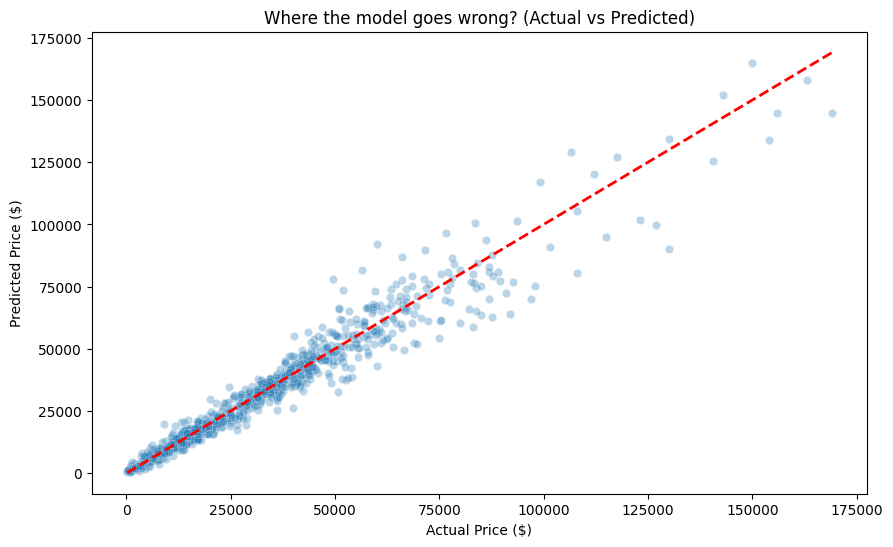

make
Tesla           0.039954
Aston Martin    0.071212
Ferrari         0.077317
Bentley         0.093761
Rolls-Royce     0.093985
Maserati        0.098198
Land Rover      0.146904
Porsche         0.158355
Name: percent_error, dtype: float64


In [13]:
# luxury model
X = df_luxury[features]
y = df_luxury['sellingprice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_luxury.fit(X_train, y_train)
y_pred = model_luxury.predict(X_test)

print(f"Bład MAE: {mean_absolute_error(y_test, y_pred):.2f}$")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# CALCULATE PERCENTAGE ERROR
results = pd.DataFrame({'actual': y_test, 'predicted': y_pred})
results['error'] = results['actual'] - results['predicted']
results['abs_error'] = results['error'].abs()
results['percent_error'] = (results['abs_error'] / results['actual']) * 100

print(f"Mean absolute percentage error (MAPE): {results['percent_error'].mean():.2f}%")

# ACTUAL vs PREDICTED CHART
plt.figure(figsize=(10,6))
sns.scatterplot(x='actual', y='predicted', data=results, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title("Where the model goes wrong? (Actual vs Predicted)")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.show()

# PERCENTAGE ERROR BY BRAND
results_make = X_test.copy()
results_make['actual'] = y_test
results_make['predicted'] = y_pred
results_make['error'] = results_make['actual'] - results_make['predicted']
results_make['abs_error'] = results_make['error'].abs()
results_make['percent_error'] = results_make['abs_error'] / results_make['actual']
results_make = results_make.groupby('make')['percent_error'].mean()

print(results_make.sort_values())

Bład MAE: 1597.82$
R2 Score: 0.9100
Mean absolute percentage error (MAPE): 16.39%


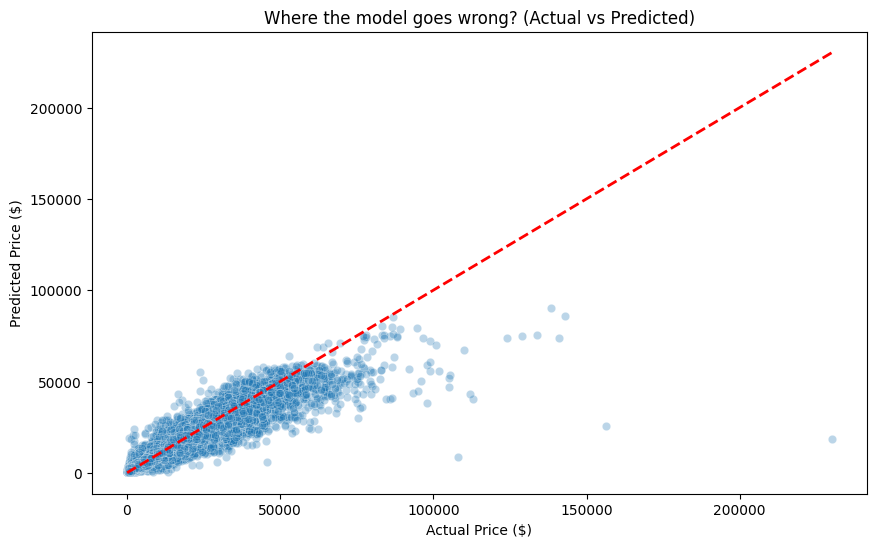

make
Infiniti         0.084202
Lexus            0.105913
Ram              0.120021
Acura            0.131015
Mini             0.131717
Kia              0.132503
Fiat             0.137060
Nissan           0.138306
Toyota           0.138746
Mercedes-Benz    0.141205
Bmw              0.142530
Hyundai          0.143784
Honda            0.159491
Subaru           0.164816
Hummer           0.166164
Smart            0.170359
Ford             0.170540
Lincoln          0.171377
Jeep             0.171727
Audi             0.174495
Mazda            0.174502
Scion            0.176100
Gmc              0.176164
Volkswagen       0.181269
Chevrolet        0.181653
Dodge            0.185469
Chrysler         0.197621
Mitsubishi       0.200098
Buick            0.204615
Volvo            0.205880
Geo              0.212707
Jaguar           0.216986
Cadillac         0.224165
Fisker           0.254311
Pontiac          0.304984
Saturn           0.328451
Suzuki           0.329142
Mercury          0.333854
Saab   

In [14]:
# normal model
X = df_normal[features]
y = df_normal['sellingprice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_normal.fit(X_train, y_train)
y_pred = model_normal.predict(X_test)

print(f"Bład MAE: {mean_absolute_error(y_test, y_pred):.2f}$")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# CALCULATE PERCENTAGE ERROR
results = pd.DataFrame({'actual': y_test, 'predicted': y_pred})
results['error'] = results['actual'] - results['predicted']
results['abs_error'] = results['error'].abs()
results['percent_error'] = (results['abs_error'] / results['actual']) * 100

print(f"Mean absolute percentage error (MAPE): {results['percent_error'].mean():.2f}%")

# ACTUAL vs PREDICTED CHART
plt.figure(figsize=(10,6))
sns.scatterplot(x='actual', y='predicted', data=results, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title("Where the model goes wrong? (Actual vs Predicted)")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.show()

# PERCENTAGE ERROR BY BRAND
results_make = X_test.copy()
results_make['actual'] = y_test
results_make['predicted'] = y_pred
results_make['error'] = results_make['actual'] - results_make['predicted']
results_make['abs_error'] = results_make['error'].abs()
results_make['percent_error'] = results_make['abs_error'] / results_make['actual']
results_make = results_make.groupby('make')['percent_error'].mean()

print(results_make.sort_values())

In [ ]:
# UPLOADING MODEL TO AWS
model_filename = 'car_valuation_model.joblib'
BUCKET = "konrad-ds-project-data"
joblib.dump(pipeline, model_filename)

s3 = boto3.client('s3')
s3.upload_file(model_filename, BUCKET, f'models/{model_filename}')
print("The model has been upload to S3.")